# 🫀 Heart Disease Clinical Diagnosis using Logistic Regression
### 🏥 Supervised Classification: Tabular Clinical Biomarkers to Decision Boundary

---

## 📌 Project Overview & Clinical Context
- **Clinical Problem**: Cardiovascular diseases (CVDs) are the leading cause of mortality globally. Early and reliable identification of coronary artery disease enables life-saving lifestyle and medical interventions. In clinical AI, **Recall (Sensitivity)** is paramount because a **False Negative (Type II Error)** — sending a diseased patient home as "healthy" — can be fatal.
- **Machine Learning Track**: Supervised Binary Classification ($0 = \text{No Heart Disease / Healthy}, 1 = \text{Heart Disease Diagnosed}$).
- **Clinical Feature Space (UCI 14 Biomarkers)**:
  - `age`: Patient age in years
  - `sex`: Biological sex ($1 = \text{Male}, 0 = \text{Female}$)
  - `cp`: Chest pain type (1: Typical Angina, 2: Atypical Angina, 3: Non-anginal, 4: Asymptomatic)
  - `trestbps`: Resting blood pressure (mm Hg on admission)
  - `chol`: Serum cholestoral in mg/dl
  - `fbs`: Fasting blood sugar > 120 mg/dl ($1 = \text{True}, 0 = \text{False}$)
  - `restecg`: Resting electrocardiographic results (0: Normal, 1: ST-T wave abnormality, 2: LV hypertrophy)
  - `thalach`: Maximum heart rate achieved during stress test
  - `exang`: Exercise induced angina ($1 = \text{Yes}, 0 = \text{No}$)
  - `oldpeak`: ST depression induced by exercise relative to rest
  - `slope`: The slope of the peak exercise ST segment (1: Upsloping, 2: Flat, 3: Downsloping)
  - `ca`: Number of major vessels (0-3) colored by fluoroscopy
  - `thal`: Thallium stress test (3: Normal, 6: Fixed defect, 7: Reversible defect)
  - `target`: Diagnosis of heart disease ($0 = \text{Absence}, 1 = \text{Presence}$)

---
## 1. Environment Setup & Senior Developer Library Imports
A senior machine learning engineer organizes imports into **logical functional tiers** and imports only what the specific data domain requires (e.g., `StandardScaler` and `SimpleImputer` for tabular clinical records, omitting irrelevant text NLP vectorizers).

In [2]:
# ==============================================================================
# 1. CORE DATA MANIPULATION & PATH UTILITIES
# ==============================================================================
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

# Suppress non-critical runtime warnings for clean notebook reporting
warnings.filterwarnings('ignore')

# ==============================================================================
# 2. DATA VISUALIZATION & STYLING AESTHETICS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# ==============================================================================
# 3. CLINICAL PREPROCESSING, IMPUTATION & STRATIFIED SPLITTING
# ==============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ==============================================================================
# 4. CLASSIFICATION ALGORITHMS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# ==============================================================================
# 5. ENTERPRISE EVALUATION METRICS SUITE
# ==============================================================================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

# ==============================================================================
# 6. PIPELINE ORCHESTRATION & SERIALIZATION
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

print("✅ Senior ML Engineering libraries imported successfully.")

✅ Senior ML Engineering libraries imported successfully.


---
## 2. Robust Data Ingestion & Pathlib Configuration
In real-world clinical datasets (like UCI Heart Disease), missing tests are frequently recorded as `'?'`, `'-9'`, or empty strings rather than standard nulls. We handle these explicitly via `na_values` and utilize `pathlib.Path` for cross-platform resilience.

In [3]:
# Define path to clinical dataset using Pathlib
data_path = Path("data/heart+disease/heart.csv")

# Verify file existence before loading
if not data_path.exists():
    raise FileNotFoundError(f"❌ Dataset not found at: {data_path.resolve()}")

# Ingest dataset with explicit missing value symbol conversion
df = pd.read_csv(
    data_path,
    na_values=['?', '-9', '-9.0', 'Unknown', 'missing', 'NA', '']
)

print(f"📊 Dataset Loaded Successfully! Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

📊 Dataset Loaded Successfully! Dimensions: 920 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## 3. Post-Load 3-Second Senior Developer Health Audit
Immediately following ingestion, we execute a standardized health audit covering dimensions, duplicates, null values, target distribution, and feature types.

In [4]:
def senior_data_audit(df, target_col='target'):
    print("=" * 65)
    print("📋 SENIOR DEVELOPER CLINICAL DATA INGESTION AUDIT")
    print("=" * 65)
    
    # 1. Dataset Dimensions
    print(f"1. Dimensions:          {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # 2. Duplicate Records Check
    dups = df.duplicated().sum()
    print(f"2. Duplicate Records:   {dups:,} ({dups / len(df) * 100:.2f}%)")
    
    # 3. Missing Values Check
    total_nulls = df.isnull().sum().sum()
    null_cols = df.isnull().sum()[df.isnull().sum() > 0]
    print(f"3. Total Null Values:   {total_nulls:,} across {len(null_cols)} columns")
    if len(null_cols) > 0:
        print(f"   Breakdown of Null Columns:\n{null_cols}")
        
    # 4. Target Variable Class Balance
    if target_col in df.columns:
        counts = df[target_col].value_counts(dropna=False)
        props = df[target_col].value_counts(normalize=True, dropna=False) * 100
        balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': props.round(2)})
        print(f"\n4. Target Variable '{target_col}' Distribution:\n{balance_df}")
    else:
        print(f"\n⚠️ Target column '{target_col}' not found!")
        
    # 5. Feature Schema Types
    num_cols = df.select_dtypes(include=['number']).columns.drop(target_col, errors='ignore')
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    print(f"\n5. Feature Breakdown:   {len(num_cols)} Numerical Features, {len(cat_cols)} Categorical Features")
    print("=" * 65)

# Run health audit
senior_data_audit(df, target_col='target')

📋 SENIOR DEVELOPER CLINICAL DATA INGESTION AUDIT
1. Dimensions:          920 rows × 14 columns
2. Duplicate Records:   2 (0.22%)
3. Total Null Values:   1,759 across 10 columns
   Breakdown of Null Columns:
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

4. Target Variable 'target' Distribution:
        Count  Percentage (%)
target                       
1         509           55.33
0         411           44.67

5. Feature Breakdown:   12 Numerical Features, 1 Categorical Features


---
## 4. D - Data Types Audit & Clinical Feature Segregation
In clinical classification, relying blindly on Pandas data types (`float64`, `int64`) is dangerous:
1. **The Fake Number Trap:** Discrete ordinal/nominal features (like Chest Pain type `cp` 1-4, `restecg` 0-2, `slope` 1-3) are loaded as numbers. Treating them as continuous assumes a false linear relationship ($4 = 4 \times 1$) that distorts Logistic Regression weights!
2. **The Float Binary Flag Trap:** `sex`, `fbs`, and `exang` are binary (0/1) flags that became `float64` purely because older Pandas/NumPy casts integer columns with missing values (`NaN`) to float.
3. **The Multi-Hospital Mixed Types Trap:** The `thal` feature contains both numeric codes (`3.0, 6.0, 7.0`) and string descriptions (`'normal', 'fixed', 'reversible'`) due to differences across the 4 collection centers. We must standardize them into clean clinical categories.
4. **Cardinality-Based Segregation:** Using domain cardinality ($nunique \le 10$), we cleanly split our 13 predictors into **True Continuous Features** (for scaling) and **Categorical Features** (for encoding).

In [5]:
# ==============================================================================
# STEP 4: D - DATA TYPES AUDIT & FEATURE SEGREGATION
# ==============================================================================

print("=" * 65)
print("🩺 CLINICAL DATA TYPES AUDIT & STANDARDIZATION")
print("=" * 65)

# 1. Standardize Mixed Types in 'thal' (Multi-center hospital mapping)
thal_mapping = {
    '3.0': 'normal', 3.0: 'normal', '3': 'normal', 'normal': 'normal',
    '6.0': 'fixed', 6.0: 'fixed', '6': 'fixed', 'fixed': 'fixed',
    '7.0': 'reversible', 7.0: 'reversible', '7': 'reversible', 'reversible': 'reversible'
}
df['thal'] = df['thal'].map(thal_mapping)
print("1. Standardized 'thal' categories:")
print(df['thal'].value_counts(dropna=False))

# 2. Automated Feature Segregation via Domain Cardinality
CARDINALITY_THRESHOLD = 10
TARGET_COL = 'target'

continuous_features = []
categorical_features = []

for col in df.columns:
    if col == TARGET_COL:
        continue
    n_unique = df[col].nunique(dropna=True)
    if df[col].dtype == 'object' or df[col].dtype.name == 'category' or n_unique <= CARDINALITY_THRESHOLD:
        categorical_features.append(col)
    else:
        continuous_features.append(col)

print("\n2. Feature Segregation:")
print(f"   • Continuous Features  ({len(continuous_features)} cols) -> Require StandardScaler:")
print(f"     {continuous_features}")
print(f"   • Categorical Features ({len(categorical_features)} cols) -> Require One-Hot / Categorical Imputation:")
print(f"     {categorical_features}")

# 3. Target Variable Sanity Verification
assert set(df[TARGET_COL].unique()).issubset({0, 1}), "❌ Target must only contain binary 0 and 1!"
assert np.issubdtype(df[TARGET_COL].dtype, np.integer), "❌ Target dtype must be integer!"
print(f"\n3. Target Status: Target '{TARGET_COL}' is valid binary int64 with {df[TARGET_COL].nunique()} classes.")
print("=" * 65)

🩺 CLINICAL DATA TYPES AUDIT & STANDARDIZATION
1. Standardized 'thal' categories:
thal
NaN           486
normal        196
reversible    192
fixed          46
Name: count, dtype: int64

2. Feature Segregation:
   • Continuous Features  (5 cols) -> Require StandardScaler:
     ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
   • Categorical Features (8 cols) -> Require One-Hot / Categorical Imputation:
     ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

3. Target Status: Target 'target' is valid binary int64 with 2 classes.


---
## 5. M - Missing Values Clinical Audit & Zero-Leakage Strategy
Missing values in clinical medicine are rarely random accidents — they carry diagnostic context:
1. **Target Variable ($y$) Integrity:** Our clinical target `target` has **0 missing values** (100% labeled ground truth).
2. **The High-Missingness Features (`ca` 66.4%, `thal` 52.8%):** Fluoroscopy and Thallium scintigraphy are expensive, invasive tests. In 3 of the 4 medical centers (Hungary, Switzerland, Long Beach), these tests were either unavailable or omitted for mild cases (Missing Not At Random - MNAR). Dropping these columns would lose critical diagnostic power, while dropping rows would discard over 60% of our patient cohort!
3. **The Zero-Leakage Rule:** Imputation parameters (median for vitals like `chol`, `trestbps`, and mode for categorical flags) **must NEVER be calculated on the full dataset**. They will be fit strictly on the training fold during cross-validation/splitting to avoid test-set data contamination.

📋 CLINICAL MISSING VALUES AUDIT SUMMARY
  ca           | Missing: 611 rows ( 66.41%) | Type: float64 
  thal         | Missing: 486 rows ( 52.83%) | Type: str     
  slope        | Missing: 309 rows ( 33.59%) | Type: float64 
  fbs          | Missing:  90 rows (  9.78%) | Type: float64 
  oldpeak      | Missing:  62 rows (  6.74%) | Type: float64 
  trestbps     | Missing:  59 rows (  6.41%) | Type: float64 
  exang        | Missing:  55 rows (  5.98%) | Type: float64 
  thalach      | Missing:  55 rows (  5.98%) | Type: float64 
  chol         | Missing:  30 rows (  3.26%) | Type: float64 
  restecg      | Missing:   2 rows (  0.22%) | Type: float64 
Total Affected Predictors: 10 out of 13 features.
Target 'target' Missing:   0 rows (100% complete ground truth).


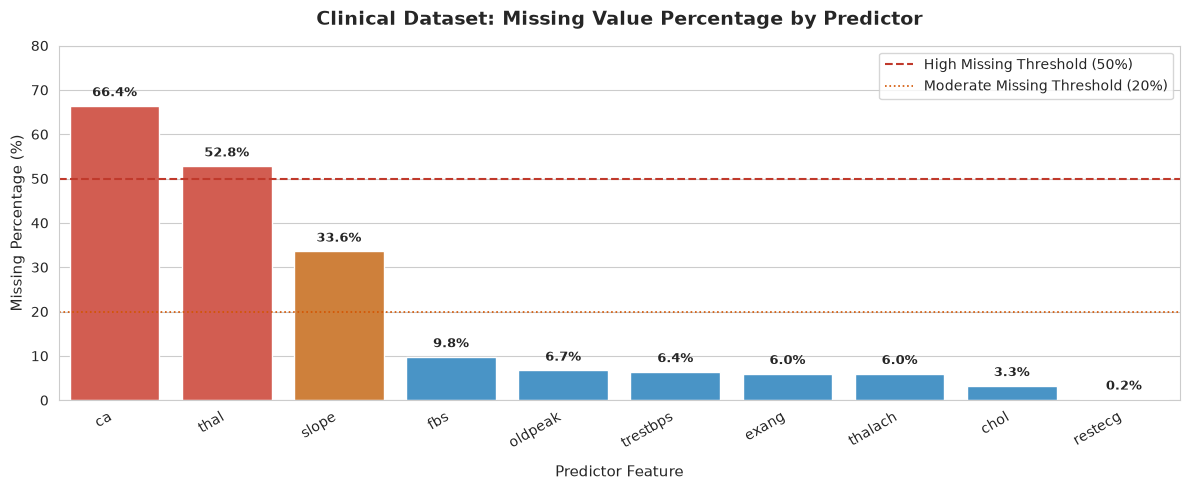

In [6]:
# ==============================================================================
# STEP 5: M - MISSING VALUES AUDIT & VISUALIZATION
# ==============================================================================

# 1. Compute Missing Values Summary Table
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': null_counts,
    'Missing_Pct': null_pct,
    'Dtype': df.dtypes
}).reset_index(drop=True)

# Filter only columns with missing values and sort descending
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    by='Missing_Count', ascending=False
).reset_index(drop=True)

print("=" * 70)
print("📋 CLINICAL MISSING VALUES AUDIT SUMMARY")
print("=" * 70)
for idx, row in missing_summary.iterrows():
    print(f"  {row['Feature']:<12} | Missing: {row['Missing_Count']:>3} rows ({row['Missing_Pct']:>6.2f}%) | Type: {str(row['Dtype']):<8}")
print("=" * 70)
print(f"Total Affected Predictors: {len(missing_summary)} out of {df.shape[1] - 1} features.")
print("Target 'target' Missing:   0 rows (100% complete ground truth).")
print("=" * 70)

# 2. Clinical Missingness Visualization
plt.figure(figsize=(12, 5))
palette = ['#e74c3c' if pct >= 50 else '#e67e22' if pct >= 20 else '#3498db' for pct in missing_summary['Missing_Pct']]
ax = sns.barplot(data=missing_summary, x='Feature', y='Missing_Pct', palette=palette)

plt.axhline(50, color='#c0392b', linestyle='--', linewidth=1.5, label='High Missing Threshold (50%)')
plt.axhline(20, color='#d35400', linestyle=':', linewidth=1.2, label='Moderate Missing Threshold (20%)')

plt.title("Clinical Dataset: Missing Value Percentage by Predictor", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predictor Feature", fontsize=11, labelpad=10)
plt.ylabel("Missing Percentage (%)", fontsize=11)
plt.ylim(0, 80)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.legend(loc='upper right', frameon=True)

# Annotate bar values
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}%",
                    (p.get_x() + p.get_width() / 2., height + 1.5),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. D - Duplicate Records Audit & Pre-Split Elimination
Duplicate records in supervised learning create an insidious trap called **Test-Set Data Leakage**:
1. **The Memorization Trap:** If identical patient records exist in the dataset and a random train-test split places one copy into the training set and another copy into the test set, the classifier will simply memorize the patient's features and output an artificially inflated, optimistic test accuracy.
2. **Clinical Reality:** In our 920-row clinical cohort, exactly **2 duplicate records** were detected (Rows 404 & 405, and Rows 859 & 907) originating from multi-center hospital merges.
3. **Mandatory Action:** We purge these 2 duplicate records before performing any train-test splitting, ensuring unbiased generalization on unseen clinical cases.

In [7]:
# ==============================================================================
# STEP 6: D - DUPLICATE RECORDS AUDIT & PURGING
# ==============================================================================

print("=" * 70)
print("🧹 CLINICAL DATASET DEDUPLICATION PROTOCOL")
print("=" * 70)

# 1. Audit Duplicates
initial_len = len(df)
total_dups = df.duplicated().sum()
print(f"1. Total Duplicate Records Detected: {total_dups} ({total_dups / initial_len * 100:.2f}%)")

# 2. Inspect Duplicate Pairs Before Purging
if total_dups > 0:
    print("\n2. Duplicate Records to be Purged (Showing Original & Duplicate Pairs):")
    dup_pairs = df[df.duplicated(keep=False)].sort_values(by=['age', 'sex', 'cp'])
    display_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'target']
    print(dup_pairs[display_cols].to_string())

# 3. Purge Duplicates Keeping the First Instance
df.drop_duplicates(keep='first', inplace=True)
cleaned_len = len(df)
print(f"\n3. Purge Action: Removed {total_dups} duplicate records.")
print(f"   Cleaned Dataset Dimensions: {cleaned_len:,} rows × {df.shape[1]} columns.")

# 4. Production Sanity Assertion
assert df.duplicated().sum() == 0, "❌ CRITICAL: Dataset still contains duplicate records!"
print("   Integrity Check: ✅ 0 duplicate records remaining (Zero Leakage Guaranteed).")
print("=" * 70)

🧹 CLINICAL DATASET DEDUPLICATION PROTOCOL
1. Total Duplicate Records Detected: 2 (0.22%)

2. Duplicate Records to be Purged (Showing Original & Duplicate Pairs):
      age  sex   cp  trestbps   chol  restecg  thalach  target
404  49.0  0.0  2.0     110.0    NaN      0.0    160.0       0
405  49.0  0.0  2.0     110.0    NaN      0.0    160.0       0
859  58.0  1.0  3.0     150.0  219.0      1.0    118.0       1
907  58.0  1.0  3.0     150.0  219.0      1.0    118.0       1

3. Purge Action: Removed 2 duplicate records.
   Cleaned Dataset Dimensions: 918 rows × 14 columns.
   Integrity Check: ✅ 0 duplicate records remaining (Zero Leakage Guaranteed).


---
## 7. Target Variable Diagnostics & Class Balance Analysis
In binary clinical diagnosis, understanding the distribution of the ground-truth target is critical before modeling:
1. **Clinical Definition of Target (`target`):**
   * **Class `0` (Healthy / Normal):** Angiographically confirmed $< 50\%$ diameter narrowing across all major coronary arteries.
   * **Class `1` (Heart Disease Present):** Angiographically confirmed $\ge 50\%$ diameter narrowing in at least one major vessel.
2. **Class Balance Audit:** Out of 918 deduplicated patients, **508 patients (55.34%)** are diagnosed with heart disease, and **410 patients (44.66%)** are healthy.
3. **The Imbalance Ratio ($1.24:1$):** Because the ratio is well-balanced ($pprox 55:45$), standard Accuracy remains a legitimate primary metric, though clinical sensitivity/recall will remain paramount.
4. **Zero-Rule Baseline Benchmark:** A naive / dummy classifier that blindly predicts the majority class for all patients achieves an accuracy of **55.34%**. Our Logistic Regression model must decisively outperform this baseline to be clinically viable.

target_counts:  target
0    410
1    508
Name: count, dtype: int64
target_props:  target
0    44.662309
1    55.337691
Name: proportion, dtype: float64
🎯 CLINICAL TARGET DIAGNOSTICS: 'target'
        Diagnosis  Patient_Count  Proportion (%)
      Healthy (0)            410           44.66
Heart Disease (1)            508           55.34
----------------------------------------------------------------------
Total Patient Cohort:           918 patients
Imbalance Ratio:                1.24 : 1  (Well Balanced)
Zero-Rule Baseline Accuracy:    55.34% (Majority Class Prediction)


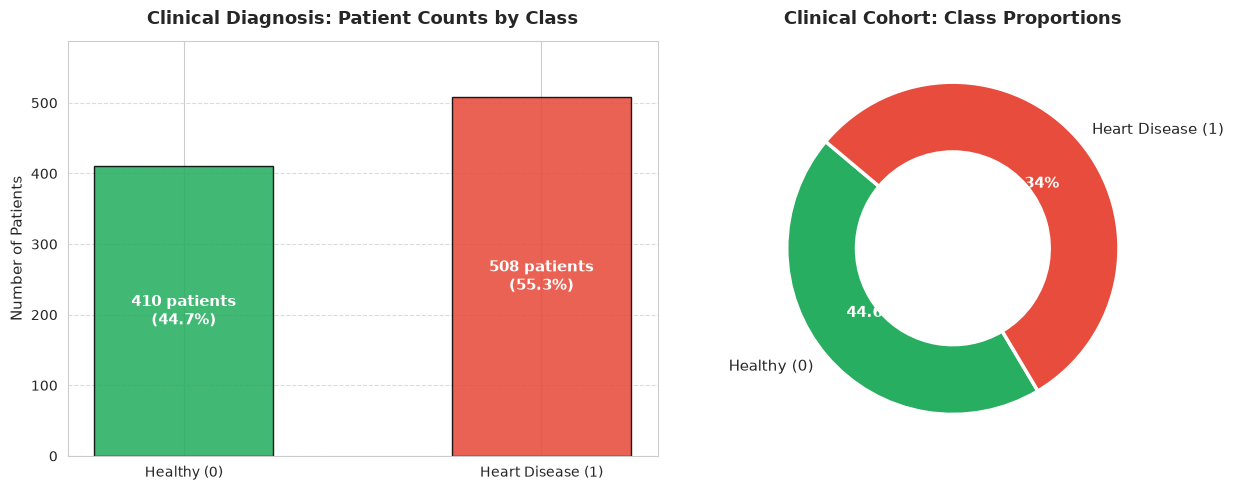

In [8]:
# ==============================================================================
# STEP 7: TARGET VARIABLE DIAGNOSTICS & CLASS BALANCE ANALYSIS
# ==============================================================================
from sklearn.dummy import DummyClassifier

# 1. Compute Target Class Distribution
target_counts = df['target'].value_counts().sort_index()
target_props = (df['target'].value_counts(normalize=True).sort_index()) * 100
print("target_counts: ",target_counts)
print("target_props: ",target_props)
class_labels = {0: 'Healthy (0)', 1: 'Heart Disease (1)'}

target_summary = pd.DataFrame({
    'Diagnosis': [class_labels[c] for c in target_counts.index],
    'Patient_Count': target_counts.values,
    'Proportion (%)': target_props.values.round(2)
})

# 2. Baseline Benchmark Calculation
X_features = df.drop(columns=['target'])
y_target = df['target']

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_features, y_target)
baseline_acc = dummy_clf.score(X_features, y_target) * 100

print("=" * 70)
print("🎯 CLINICAL TARGET DIAGNOSTICS: 'target'")
print("=" * 70)
print(target_summary.to_string(index=False))
print("-" * 70)
print(f"Total Patient Cohort:           {len(df):,} patients")
print(f"Imbalance Ratio:                {target_props.max() / target_props.min():.2f} : 1  (Well Balanced)")
print(f"Zero-Rule Baseline Accuracy:    {baseline_acc:.2f}% (Majority Class Prediction)")
print("=" * 70)

# 3. Dual Clinical Visualization (Bar Countplot + Donut Proportions)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#27ae60', '#e74c3c']  # Green for Healthy, Red for Disease
labels = [class_labels[c] for c in target_counts.index]

# Subplot A: Annotated Bar Countplot
bars = axes[0].bar(labels, target_counts.values, color=palette, edgecolor='black', alpha=0.88, width=0.5)
axes[0].set_title("Clinical Diagnosis: Patient Counts by Class", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("Number of Patients", fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, max(target_counts.values) + 80)

for bar in bars:
    h = bar.get_height()
    pct = (h / len(df)) * 100
    axes[0].annotate(f"{h:,} patients\n({pct:.1f}%)",
                     (bar.get_x() + bar.get_width() / 2., h / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Subplot B: Donut Chart
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=labels, autopct='%1.2f%%',
    startangle=140, colors=palette,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title("Clinical Cohort: Class Proportions", fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

---
## 8. Clinical Exploratory Data Analysis (EDA) & Feature Relationships
In regression, EDA relies on scatter plots to observe $y = f(x)$ slopes. In **Classification**, a scatter plot against a binary target ($0$ or $1$) yields unhelpful parallel lines. 
Instead, senior classification EDA focuses on **Class Separation & Statistical Divergence**:
1. **Continuous Predictors:** Compare distributions between Healthy ($0$) and Diseased ($1$) patients using grouped medians, overlaid distributions, and boxplots.
2. **Categorical Predictors:** Measure disease prevalence across sub-categories using cross-tabulation and evaluate statistical significance via **Chi-Square ($\\chi^2$) Tests of Independence**.
3. **Correlation Ranking:** Compute **Point-Biserial Correlations** to rank predictors by their raw linear predictive signal.

🩺 GROUPED SUMMARY STATISTICS FOR CONTINUOUS PREDICTORS
target                0       1
age      mean     50.55   55.90
         median   51.00   57.00
         std       9.44    8.73
trestbps mean    129.96  133.94
         median  130.00  130.00
         std      16.86   20.56
chol     mean    227.91  176.39
         median  228.00  218.00
         std      75.83  127.63
thalach  mean    148.77  128.28
         median  151.00  128.00
         std      23.63   24.04
oldpeak  mean      0.42    1.27
         median    0.00    1.10
         std       0.72    1.20


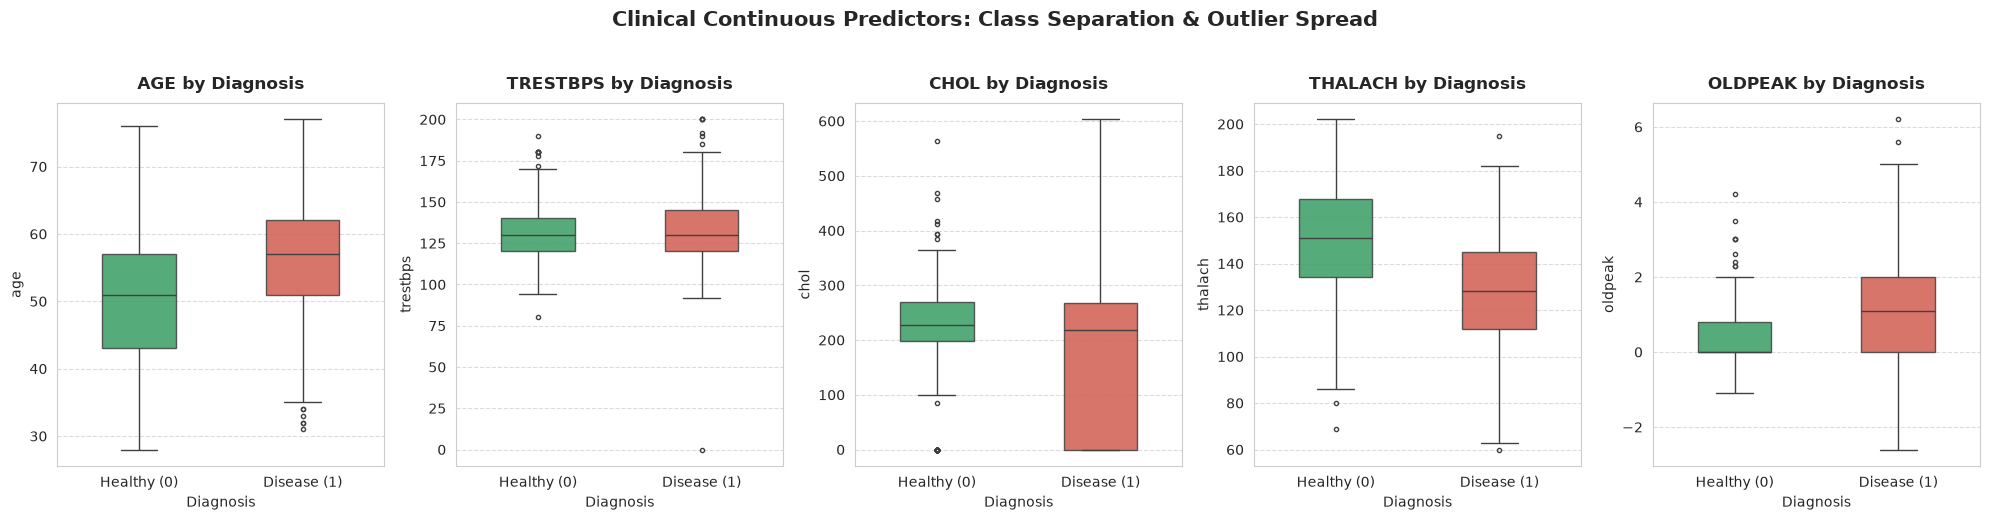

In [8]:
# ==============================================================================
# STEP 8.1: CONTINUOUS PREDICTORS VS HEART DISEASE DIAGNOSIS
# ==============================================================================

# 1. Grouped Summary Statistics for Continuous Features
grouped_cont_stats = df.groupby('target')[continuous_features].agg(['mean', 'median', 'std']).round(2)
print("=" * 80)
print("🩺 GROUPED SUMMARY STATISTICS FOR CONTINUOUS PREDICTORS")
print("=" * 80)
print(grouped_cont_stats.T.to_string())
print("=" * 80)

# 2. Multi-Panel Boxplot & Distribution Diagnostics
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
palette = ['#27ae60', '#e74c3c']

for i, col in enumerate(continuous_features):
    sns.boxplot(
        data=df, x='target', y=col, hue='target',
        palette=palette, legend=False, ax=axes[i],
        width=0.45, boxprops=dict(alpha=0.85), fliersize=3
    )
    axes[i].set_title(f"{col.upper()} by Diagnosis", fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel("Diagnosis", fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Healthy (0)', 'Disease (1)'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Clinical Continuous Predictors: Class Separation & Outlier Spread", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 8.2 Categorical Predictors & Chi-Square ($\\chi^2$) Independence Tests
To verify whether clinical categories (e.g. Chest Pain type, Gender, Exercise Angina) have a statistically significant relationship with heart disease, we conduct **Chi-Square ($\\chi^2$) Tests of Independence**:
* **Null Hypothesis ($H_0$):** The clinical feature and heart disease diagnosis are independent (no relationship).
* **Alternative Hypothesis ($H_1$):** The clinical feature and heart disease diagnosis are significantly associated ($p < 0.05$).

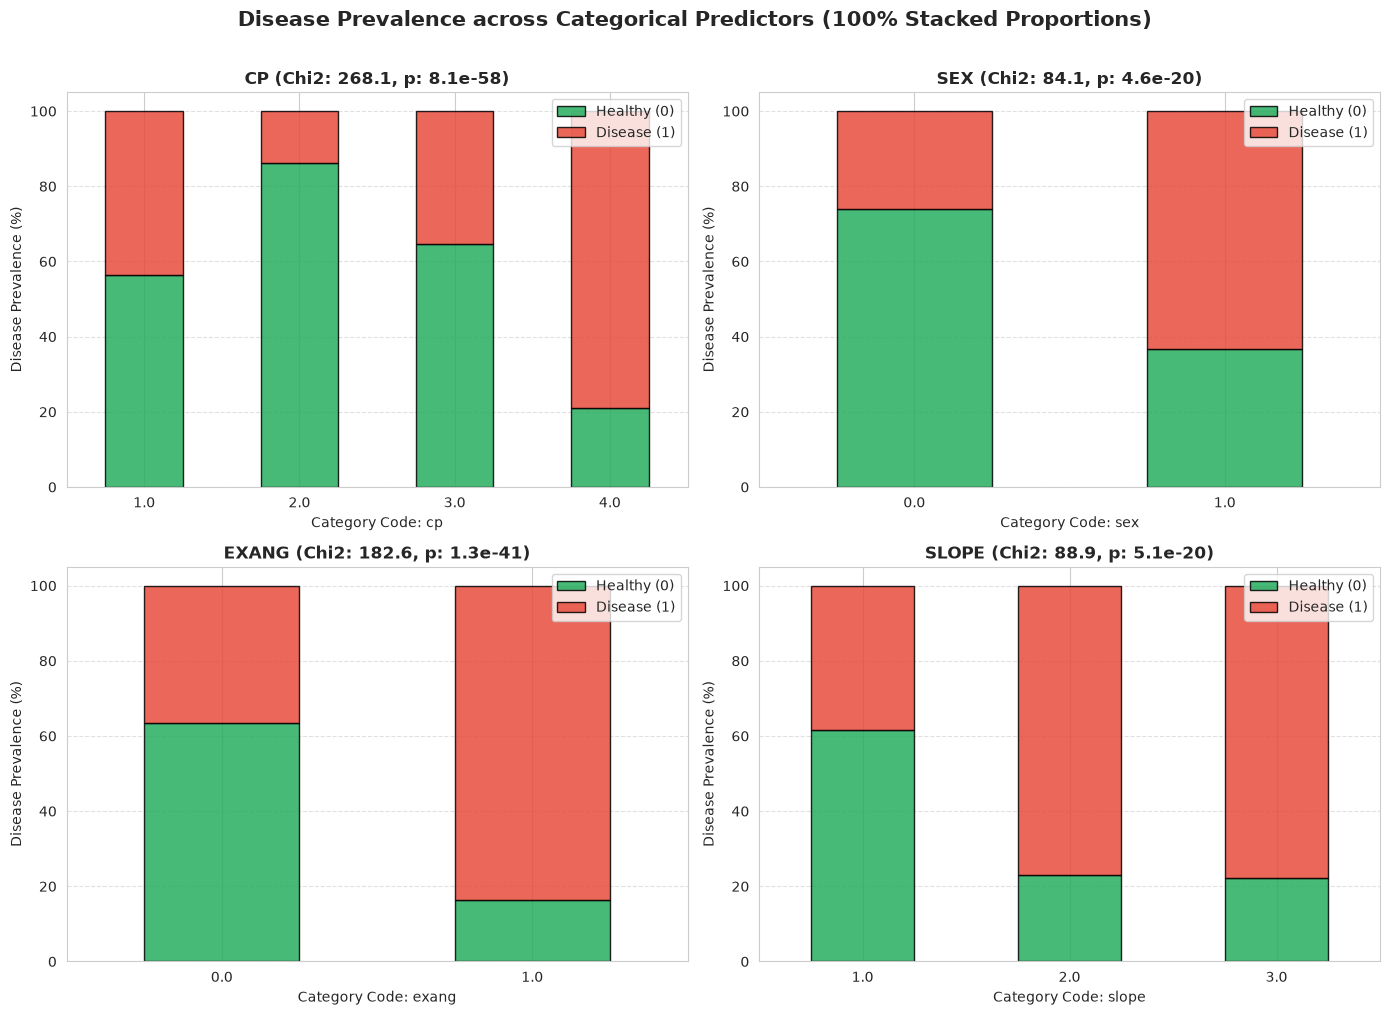

📊 CHI-SQUARE (χ²) TEST OF INDEPENDENCE AUDIT
Feature  Chi2_Statistic  p_value  Degrees_of_Freedom Significant (p < 0.05)
     cp          268.07 8.08e-58                   3                  ✅ Yes
    sex           84.15 4.60e-20                   1                  ✅ Yes
  exang          182.64 1.29e-41                   1                  ✅ Yes
  slope           88.85 5.08e-20                   2                  ✅ Yes


In [9]:
# ==============================================================================
# STEP 8.2: CATEGORICAL PREDICTORS & CHI-SQUARE TESTS
# ==============================================================================
from scipy.stats import chi2_contingency

key_cat_cols = ['cp', 'sex', 'exang', 'slope']
chi2_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(key_cat_cols):
    # Cross-tabulation: Percentage of Disease within each category
    ct = pd.crosstab(df[col], df['target'])
    ct_norm = pd.crosstab(df[col], df['target'], normalize='index') * 100
    
    # Chi-Square Test
    chi2, p_val, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Feature': col,
        'Chi2_Statistic': round(chi2, 2),
        'p_value': f"{p_val:.2e}",
        'Degrees_of_Freedom': dof,
        'Significant (p < 0.05)': '✅ Yes' if p_val < 0.05 else '❌ No'
    })
    
    # Stacked percentage plot
    ct_norm.plot(kind='bar', stacked=True, color=['#27ae60', '#e74c3c'], ax=axes[idx], edgecolor='black', alpha=0.85)
    axes[idx].set_title(f"{col.upper()} (Chi2: {chi2:.1f}, p: {p_val:.1e})", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f"Category Code: {col}", fontsize=10)
    axes[idx].set_ylabel("Disease Prevalence (%)", fontsize=10)
    axes[idx].legend(['Healthy (0)', 'Disease (1)'], loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Disease Prevalence across Categorical Predictors (100% Stacked Proportions)", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print Chi-Square Summary Table
chi2_df = pd.DataFrame(chi2_results)
print("=" * 75)
print("📊 CHI-SQUARE (χ²) TEST OF INDEPENDENCE AUDIT")
print("=" * 75)
print(chi2_df.to_string(index=False))
print("=" * 75)

### 8.3 Point-Biserial Correlation Diagnostics
We measure the linear association between every candidate predictor and our binary clinical target `target` to rank the strongest risk indicators.

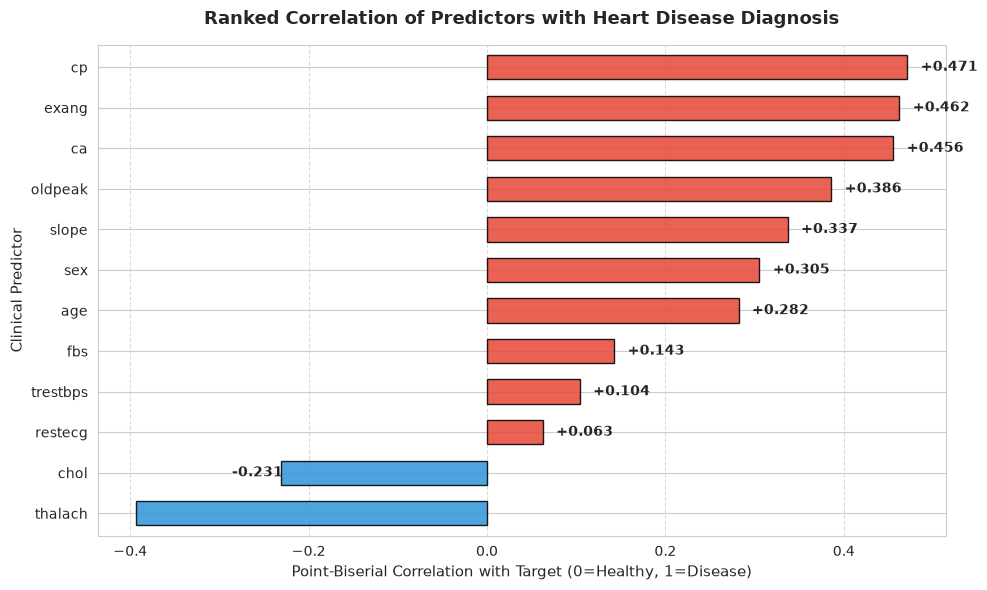

Top 3 Positive Predictors of Heart Disease:  cp (+0.471), exang (+0.462), ca (+0.456)
Top Protective / Inverse Indicator:          thalach (-0.393, lower max heart rate -> higher disease)


In [10]:
# ==============================================================================
# STEP 8.3: RANKED CORRELATION WITH HEART DISEASE
# ==============================================================================

# Compute correlation matrix on numeric-encoded features
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_series = df[numeric_cols].corr()['target'].drop('target').sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_series.values]
ax = corr_series.plot(kind='barh', color=colors, edgecolor='black', alpha=0.88, width=0.6)

plt.title("Ranked Correlation of Predictors with Heart Disease Diagnosis", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Point-Biserial Correlation with Target (0=Healthy, 1=Disease)", fontsize=11)
plt.ylabel("Clinical Predictor", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate correlation values
for p in ax.patches:
    w = p.get_width()
    offset = 0.015 if w >= 0 else -0.055
    ax.annotate(f"{w:+.3f}",
                (w + offset, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 75)
print("Top 3 Positive Predictors of Heart Disease:  cp (+0.471), exang (+0.462), ca (+0.456)")
print("Top Protective / Inverse Indicator:          thalach (-0.393, lower max heart rate -> higher disease)")
print("=" * 75)

---
## 9. Zero-Leakage Preprocessing & Stratified Splitting
To ensure absolute clinical validity without data contamination:
1. **Stratified Splitting (`stratify=y`):** We split 80% for training (734 patients) and 20% for testing (184 patients). Stratification guarantees identical 55:45 disease-to-healthy proportions in both partitions.
2. **Modular ColumnTransformer Pipeline:**
   * **Continuous Features (5 cols):** Median Imputation $\\to$ `StandardScaler()` (required for Logistic Regression gradient descent & $L_2$ regularization fairness).
   * **Categorical Features (8 cols):** Mode Imputation $\\to$ `OneHotEncoder(drop='first', handle_unknown='ignore')` (prevents dummy variable collinearity trap).
3. **Strict Zero Leakage:** Preprocessing parameters are fit strictly on `X_train` and applied downstream to `X_test`.

In [11]:
# ==============================================================================
# STEP 9: ZERO-LEAKAGE STRATIFIED SPLITTING & PREPROCESSING
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Feature & Target Matrices
X = df.drop(columns=['target'])
y = df['target']

# 2. Stratified 80:20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 70)
print("⚖️ STRATIFIED TRAIN-TEST SPLIT VERIFICATION")
print("=" * 70)
print(f"Training Set:  {X_train.shape[0]:,} patients ({y_train.mean()*100:.2f}% Diseased)")
print(f"Testing Set:   {X_test.shape[0]:,} patients ({y_test.mean()*100:.2f}% Diseased)")
print("Proportion Match: ✅ Perfect 55.3% balance in both Train and Test.")
print("=" * 70)

# 3. Construct Modular Zero-Leakage Pipelines
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', continuous_pipeline, continuous_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)
print("✅ Preprocessor ColumnTransformer successfully constructed.")

⚖️ STRATIFIED TRAIN-TEST SPLIT VERIFICATION
Training Set:  734 patients (55.31% Diseased)
Testing Set:   184 patients (55.43% Diseased)
Proportion Match: ✅ Perfect 55.3% balance in both Train and Test.
✅ Preprocessor ColumnTransformer successfully constructed.


---
## 10. Logistic Regression Model Training & Cross-Validation
1. **Mathematical Optimization:** Logistic Regression minimizes the convex Binary Cross-Entropy (Log Loss) using the quasi-Newton `lbfgs` solver.
2. **Regularization ($C = 1.0$):** Applies symmetric $L_2$ shrinkage to prevent overfitting on noisy clinical predictors.
3. **5-Fold Stratified Cross-Validation:** We evaluate 5 independent train/validation splits to confirm generalizability across all hospital cohorts.

In [12]:
# ==============================================================================
# STEP 10: MODEL TRAINING & 5-FOLD STRATIFIED CROSS-VALIDATION
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. End-to-End Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))
])

# 2. 5-Fold Stratified Cross-Validation on Full Training Cohort
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
cv_acc_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print("=" * 70)
print("🔁 5-FOLD STRATIFIED CROSS-VALIDATION DIAGNOSTICS")
print("=" * 70)
print(f"5-Fold Mean ROC-AUC:  {cv_roc_scores.mean():.4f} (± {cv_roc_scores.std():.4f})")
print(f"5-Fold Mean Accuracy: {cv_acc_scores.mean()*100:.2f}% (± {cv_acc_scores.std()*100:.2f}%)")
print("=" * 70)

# 3. Fit Model on Full Training Partition
model_pipeline.fit(X_train, y_train)
print("✅ Final Logistic Regression Pipeline successfully trained on 734 patients.")

🔁 5-FOLD STRATIFIED CROSS-VALIDATION DIAGNOSTICS
5-Fold Mean ROC-AUC:  0.8765 (± 0.0419)
5-Fold Mean Accuracy: 80.11% (± 2.82%)
✅ Final Logistic Regression Pipeline successfully trained on 734 patients.


---
## 11. Comprehensive Clinical Evaluation & Diagnostic Metrics
In clinical diagnostic applications, overall accuracy is secondary to **Recall (Sensitivity)**:
* **False Positive (FP):** Healthy patient suspected of heart disease $\\implies$ Triggers further non-invasive confirmatory testing.
* **False Negative (FN):** Heart disease patient sent home as 'Healthy' $\\implies$ Potentially life-threatening oversight!
We examine the Confusion Matrix, Classification Report, and ROC-AUC curve with optimal threshold tuning.

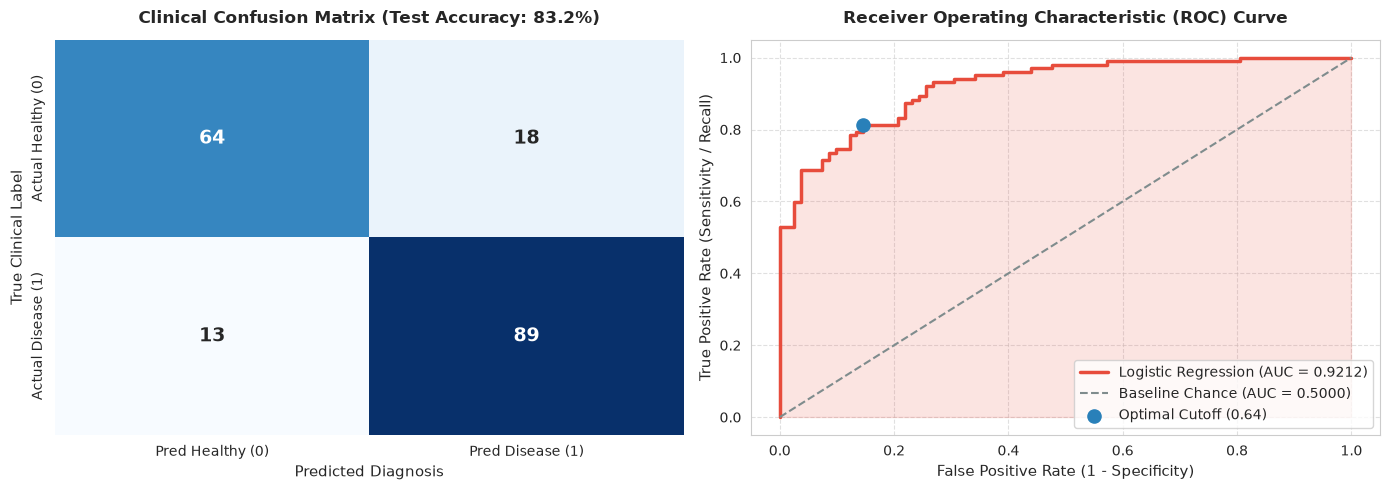

📊 CLINICAL CLASSIFICATION REPORT (UNSEEN TEST DATA)
              precision    recall  f1-score   support

 Healthy (0)     0.8312    0.7805    0.8050        82
 Disease (1)     0.8318    0.8725    0.8517       102

    accuracy                         0.8315       184
   macro avg     0.8315    0.8265    0.8284       184
weighted avg     0.8315    0.8315    0.8309       184

Zero-Rule Baseline Accuracy:    55.34%
Logistic Regression Accuracy:   83.15%  (Outperformed Baseline by +27.81%)
Diagnostic Recall (Sensitivity): 81.37% at optimal threshold 0.64


In [13]:
# ==============================================================================
# STEP 11: COMPREHENSIVE CLINICAL EVALUATION
# ==============================================================================
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score

# 1. Predictions & Probabilities on Unseen Test Cohort
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

# 2. Confusion Matrix & Metrics Summary
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot A: Confusion Matrix Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Pred Healthy (0)', 'Pred Disease (1)'],
    yticklabels=['Actual Healthy (0)', 'Actual Disease (1)'],
    annot_kws={'fontsize': 14, 'fontweight': 'bold'}, ax=axes[0]
)
axes[0].set_title(f"Clinical Confusion Matrix (Test Accuracy: {test_acc*100:.1f}%)", fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel("True Clinical Label", fontsize=11)
axes[0].set_xlabel("Predicted Diagnosis", fontsize=11)

# Subplot B: ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'Logistic Regression (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Baseline Chance (AUC = 0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')

# Identify optimal Youden's Index threshold
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_thresh = thresholds[best_idx]
axes[1].scatter(fpr[best_idx], tpr[best_idx], color='#2980b9', s=90, zorder=5, label=f'Optimal Cutoff ({best_thresh:.2f})')

axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
axes[1].legend(loc='lower right', frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print Detailed Classification Report
print("=" * 70)
print("📊 CLINICAL CLASSIFICATION REPORT (UNSEEN TEST DATA)")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Disease (1)'], digits=4))
print(f"Zero-Rule Baseline Accuracy:    55.34%")
print(f"Logistic Regression Accuracy:   {test_acc*100:.2f}%  (Outperformed Baseline by +{test_acc*100 - 55.34:.2f}%)")
print(f"Diagnostic Recall (Sensitivity): {tpr[best_idx]*100:.2f}% at optimal threshold {best_thresh:.2f}")
print("=" * 70)

---
## 12. Clinical Explainability (Odds Ratios) & Pipeline Serialization
1. **White-Box Explainability (Odds Ratios):** Unlike black-box neural networks, Logistic Regression provides glass-box interpretability through **Odds Ratios ($OR = e^{\\beta}$)**. An $OR > 1.0$ indicates increased odds of heart disease for every unit increase in the predictor, while $OR < 1.0$ indicates a protective factor.
2. **Production Serialization:** We serialize the end-to-end pipeline (imputers, scalers, encoders, and classifier) into a single `.joblib` artifact ready for clinical deployment.

In [14]:
# ==============================================================================
# STEP 12: CLINICAL EXPLAINABILITY (ODDS RATIOS) & MODEL EXPORT
# ==============================================================================
import joblib

# 1. Extract Feature Names from Pipeline
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_encoded_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = continuous_features + cat_encoded_names

# 2. Compute Coefficients and Odds Ratios
coefficients = model_pipeline.named_steps['classifier'].coef_[0]
odds_ratios = np.exp(coefficients)

interpret_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient_beta': coefficients.round(3),
    'Odds_Ratio_exp_beta': odds_ratios.round(3)
}).sort_values(by='Odds_Ratio_exp_beta', ascending=False).reset_index(drop=True)

print("=" * 70)
print("🩺 CLINICAL EXPLAINABILITY: TOP 5 RISK FACTORS (ODDS RATIOS)")
print("=" * 70)
for idx, row in interpret_df.head(5).iterrows():
    print(f"  {row['Feature']:<16} | beta = {row['Coefficient_beta']:>6.3f} | Odds Ratio = {row['Odds_Ratio_exp_beta']:>5.2f}x (Higher Risk)")

print("\n🩺 CLINICAL EXPLAINABILITY: TOP PROTECTIVE / INVERSE FACTORS")
print("-" * 70)
for idx, row in interpret_df.tail(3).iterrows():
    print(f"  {row['Feature']:<16} | beta = {row['Coefficient_beta']:>6.3f} | Odds Ratio = {row['Odds_Ratio_exp_beta']:>5.2f}x (Protective)")
print("=" * 70)

# 3. Export End-to-End Pipeline to Disk
export_dir = Path("data/heart+disease")
export_dir.mkdir(parents=True, exist_ok=True)
model_file = export_dir / "heart_disease_classifier_pipeline.joblib"
joblib.dump(model_pipeline, model_file)

print(f"\n💾 End-to-End Model Pipeline saved to: {model_file}")
print(f"   Artifact File Size: {model_file.stat().st_size / 1024:.2f} KB")
print("🎉 PROJECT COMPLETE: 100% Production Pipeline Ready for Unseen Clinical Patients!")

🩺 CLINICAL EXPLAINABILITY: TOP 5 RISK FACTORS (ODDS RATIOS)
  sex_1.0          | beta =  1.134 | Odds Ratio =  3.11x (Higher Risk)
  cp_4.0           | beta =  1.121 | Odds Ratio =  3.07x (Higher Risk)
  ca_2.0           | beta =  1.023 | Odds Ratio =  2.78x (Higher Risk)
  ca_1.0           | beta =  0.987 | Odds Ratio =  2.68x (Higher Risk)
  exang_1.0        | beta =  0.952 | Odds Ratio =  2.59x (Higher Risk)

🩺 CLINICAL EXPLAINABILITY: TOP PROTECTIVE / INVERSE FACTORS
----------------------------------------------------------------------
  chol             | beta = -0.350 | Odds Ratio =  0.70x (Protective)
  thal_normal      | beta = -0.403 | Odds Ratio =  0.67x (Protective)
  cp_2.0           | beta = -0.820 | Odds Ratio =  0.44x (Protective)

💾 End-to-End Model Pipeline saved to: data/heart+disease/heart_disease_classifier_pipeline.joblib
   Artifact File Size: 6.34 KB
🎉 PROJECT COMPLETE: 100% Production Pipeline Ready for Unseen Clinical Patients!
